# Deep Learning - Exercise 4

This lecture is about advanced topics of the CNN such as transfer learning and 1D convolutions for time-series processing.

We will use CIFAR-10 dataset again and [FordA](https://www.timeseriesclassification.com/description.php?Dataset=FordA) for time-series classification task.

**Core Concepts**
* 🧠 Transfer learning techniques in CNNs
* 📈 1D Convolutions for time-series processing
* 📊 CIFAR-10 dataset utilization
* ⏱️ FordA dataset for time-series classification tasks

[Open in Google colab](https://colab.research.google.com/github/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_04.ipynb)
[Download from Github](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/dl_04.ipynb)

##### Remember to set **GPU** runtime in Colab!

In [45]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import pandas as pd
import matplotlib.pyplot as plt # plotting
import matplotlib.image as mpimg # images
import seaborn as sns # plotting
import numpy as np #numpy
import tensorflow as tf
import tensorflow.keras as keras
import requests

from tensorflow.keras.layers import Activation
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import VGG19

from sklearn.model_selection import train_test_split # split for validation sets
from sklearn.preprocessing import normalize # normalization of the matrix
from scipy.signal import convolve2d # convolutionof the 2D signals
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from PIL import Image
from io import BytesIO
from skimage.transform import resize

import matplotlib as mpl


# Reset případného dark stylu
plt.style.use("default")
mpl.rcdefaults()

# Světlé a čitelné vykreslení
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "text.color": "#222222",
    "grid.color": "#D0D0D0",
    "grid.alpha": 0.6,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})


tf.version.VERSION

'2.19.0'

In [46]:
def show_history(history):
    plt.figure()
    for key in history.history.keys():
        plt.plot(history.epoch, history.history[key], label=key)
    plt.legend()
    plt.tight_layout()

def show_example(train_x, train_y, class_names):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(train_x[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[train_y[i][0]])
    plt.show()
                
def compute_metrics(y_true, y_pred, show_confusion_matrix=False):
    print(f'\tAccuracy: {accuracy_score(y_true, y_pred)*100:8.2f}%')
    if (show_confusion_matrix):
        print('\tConfusion matrix:\n', confusion_matrix(y_true, y_pred))

# 🔎 What is *transfer learning* about? 🔎

* Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem. 
    * For instance, features from a model that has learned to identify cars may be useful to kick-start a model meant to identify trucks.
        * 🔎 Do you know any famous CNN models?

* Transfer learning is usually done for tasks where your dataset has too little data to train a full-scale model from scratch.
    * 🔎 How do we benefit from it?
    
## 📌 Usual pipeline

1) Take layers from a previously trained model.

2) Freeze them, so you avoid destroying any of the information they contain during future training rounds.

3) Add some new, trainable layers, on top of the frozen layers. 
    * 💡 They will learn how to turn the features extracted by pre-trained layers into predictions on a new dataset.

4) Train the new layers using your dataset.

* 💡 Optional step: Fine-tuning (= unfreezing the entire model you obtained above, or part of it), and re-training it on the new data with a very **low** learning rate. 
    * This can potentially achieve meaningful improvements, by incrementally adapting the pretrained features to the new data.
    * 🔎 Why do we use **low** learning rate?


# 🚀 Let's start!

## Import dataset **CIFAR10** again
* I think (or hope 😀) that you remember most of these detailes from the previous lecture 🙂
    * The CIFAR-10 dataset contains 60,000 32x32 color images in 10 different classes. 
    * The 10 different classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. 
    * There are 6,000 images of each class.

## We will resize the images into (224, 224) shape because we will use ResNet50 later and we will also one-hot encode our labels
* 💡 If you do not encode the labels you will run into shape mismatch error which is hard to debug - trust me, I've been there 🙂

In [47]:
# cifar is the basic dataset for image classifaction
dataset = tf.keras.datasets.cifar10
img_size = 224
subset = 1000
test_size = 0.2

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_count = len(class_names)

# data from any dataset are loaded using the load_Data function
(train_x, train_y), (test_x, test_y) = dataset.load_data()

train_y = tf.keras.utils.to_categorical(train_y[:subset], class_count)
test_y = tf.keras.utils.to_categorical(test_y[:subset], class_count)

train_x_resized = tf.image.resize(train_x[:subset], [img_size, img_size], )
test_x_resized = tf.image.resize(test_x[:subset], [img_size, img_size])

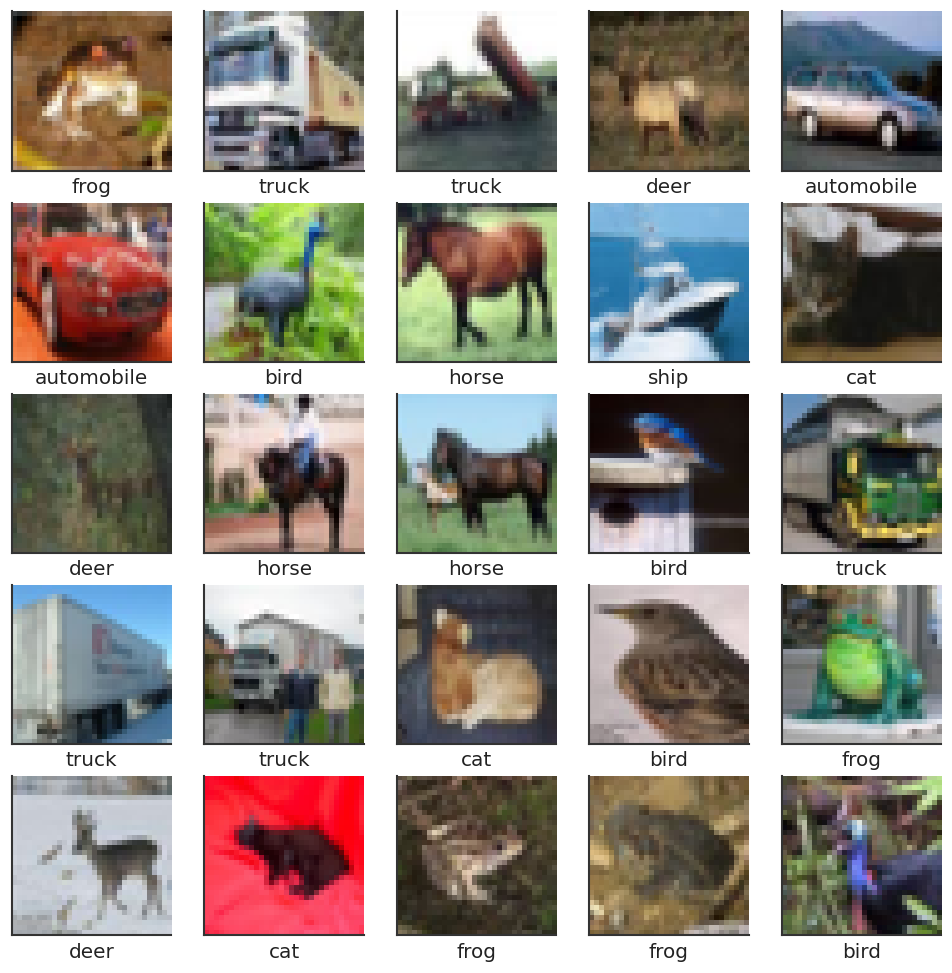

In [48]:
show_example(train_x, np.argmax(train_y, axis=1).reshape(-1, 1), class_names)

# Instantiate a `ResNet50` model with pre-trained weights.
* 🔎 What the **include_top** do?
* What means **weights='imagenet'** parameter? 
    * 🔎 Do we need it? 
    * 🔎 What happens if we use random weights?

In [49]:
base_model = ResNet50(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(img_size, img_size, 3),
    include_top=False)  # Do not include the ImageNet classifier part at the top.

## 📌 IMPORTANT: Freeze the base model 📌
* We don't want to train the encoder path of model yet

In [50]:
base_model.trainable = False

# ⚡ Create a model input and output layers and interconnect all the parts together
* 💡 We make sure that the base_model is running in inference mode here, by passing `training=False`.

## 📌 Notes about BatchNormalization layer
* Many image models contain **BatchNormalization** layers. 
* Here are a few things to keep in mind:
    * BatchNormalization contains 2 non-trainable weights that get updated during training. 
        * These are the variables **tracking the mean and variance of the inputs**.
* 💡 When you **unfreeze** a model that contains BatchNormalization layers in order to do **fine-tuning**, you should **keep the BatchNormalization layers in inference mode by passing training=False** when calling the base model. 
    * **Otherwise the updates applied to the non-trainable weights will suddenly destroy what the model has learned.**


* 🔎 What the **GlobalAveragePooling2D** layer does?
    * After convolutional operations, *tf.keras.layers.Flatten* will reshape a tensor into (n_samples, height*width*channels), for example turning (16, 28, 28, 3) into (16, 2352)
    * *GlobalAveragePooling* layer is an alternative to this because it averages all the values according to the last axis. 
        * This means that the resulting shape will be (n_samples, last_axis). 
        * 💡 For instance, if your last convolutional layer had 64 filters, it would turn (16, 7, 7, 64) into (16, 64)

# 📌 Make sure that you call the `preprocess_input` function
* Each Keras Application expects a specific kind of input preprocessing. 
* For ResNet, call `tf.keras.applications.resnet.preprocess_input` on your inputs before passing them to the model.
    * 💡 It will convert the input images from RGB to BGR, then will zero-center each color channel with respect to the ImageNet dataset, without scaling.

In [51]:
inputs = keras.Input(shape=(img_size, img_size, 3), dtype=tf.uint8)
x = keras.ops.cast(inputs, dtype=tf.float32)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(class_count, activation='softmax')(x)
model = keras.Model(inputs, outputs)

## Compile the model and check number of parameters
* Why do we have only **20,490** trainable parameters?
* Why do we use `CategoricalAccuracy` and `CategoricalCrossentropy`?

In [52]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 224, 224,  │          0 │ input_layer_12[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ cast_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ cast_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ cast_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 10)        │     20,490 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

![Meme01](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_meme_tf_01.png?raw=true)

## 💡 Always check if all the shapes match the pre-defined ranges! 
* Otherwise you will run into shape missmatch issue in the training loop and it is harder to debug than the C++ templates 😅

In [53]:
train_x_resized.shape, train_y.shape

(TensorShape([1000, 224, 224, 3]), (1000, 10))

In [54]:
test_x_resized.shape, test_y.shape

(TensorShape([1000, 224, 224, 3]), (1000, 10))

## 🚀 Fit the model

In [55]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 429ms/step - categorical_accuracy: 0.3010 - loss: 2.2314 - val_categorical_accuracy: 0.7150 - val_loss: 0.8719
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - categorical_accuracy: 0.8294 - loss: 0.5915 - val_categorical_accuracy: 0.8300 - val_loss: 0.5660
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - categorical_accuracy: 0.9001 - loss: 0.3689 - val_categorical_accuracy: 0.8300 - val_loss: 0.5086
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - categorical_accuracy: 0.9302 - loss: 0.2706 - val_categorical_accuracy: 0.8250 - val_loss: 0.4949
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - categorical_accuracy: 0.9538 - loss: 0.2096 - val_categorical_accuracy: 0.8300 - val_loss: 0.4881
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - categorical_accuracy: 0.9760 - loss: 0.1715 - val_categorical_accuracy: 0.8350 - val_loss: 0.4593
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - categorical_accuracy: 0.9906 - lo

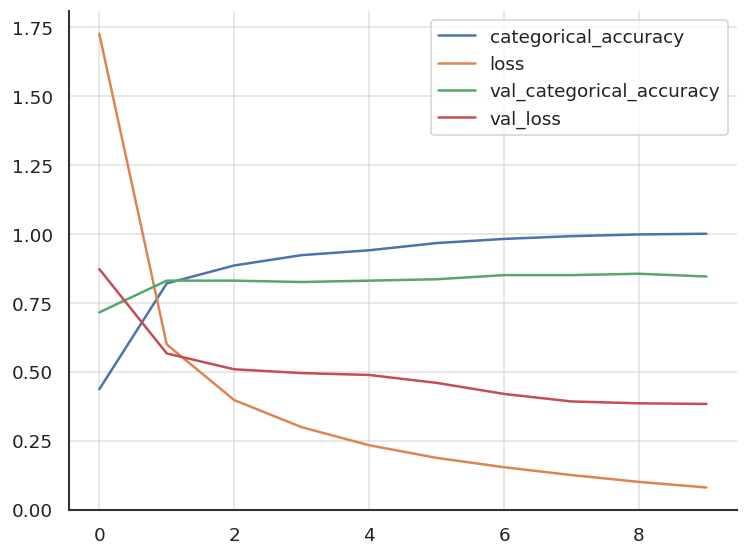

In [56]:
history = model.fit(train_x_resized, train_y, validation_split=0.2, batch_size=32, epochs=10, callbacks=[model_checkpoint_callback])

show_history(history)

# Load best setup
model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x_resized, test_y)
print('Test accuracy: ', test_acc)

# 🚀 Fine-tuning
* Once your model has converged on the new data, you can try to unfreeze all or part of the base model and retrain the whole model end-to-end with a very low learning rate.
    * 💡 It could also potentially lead to quick overfitting -- keep that in mind.
* It is critical to only do this step **after the model with frozen layers has been trained to convergence**. 
    * 💡 If you mix randomly-initialized trainable layers with trainable layers that hold pre-trained features the randomly-initialized layers will cause very large gradient updates during training, 
    * This will **destroy your pre-trained features**.
    
### It's also critical to use a *very low learning rate* at this stage, 
* You are training a much larger model than in the first round of training, on a dataset that is typically very small. 
    * 💡 As a result, you are at **risk of overfitting** very quickly if you apply large weight updates.

## Unfreeze the base model

In [57]:
base_model.trainable = True

## 💡 Recompile your model after you make any changes
* The `trainable` attribute of any inner layer is taken into account after re-compilation

* Calling `compile()` on a model is meant to "freeze" the behavior of that model. 
    * This implies that the trainable attribute values at the time the model is compiled should be preserved throughout the lifetime of that model, until compile is called again. 
    * Hence, if you change any trainable value, make sure to call `compile()` again on your model for your changes to be taken into account.

In [58]:
model.compile(optimizer=keras.optimizers.Adam(1e-5),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 224, 224,  │          0 │ input_layer_12[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ cast_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ cast_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ cast_1[0][0]      │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 10)        │     20,490 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [59]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 67s 636ms/step - categorical_accuracy: 0.6194 - loss: 1.1589 - val_categorical_accuracy: 0.8350 - val_loss: 0.4821
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step - categorical_accuracy: 0.9769 - loss: 0.2206 - val_categorical_accuracy: 0.8050 - val_loss: 0.5691
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 334ms/step - categorical_accuracy: 0.9979 - loss: 0.0960 - val_categorical_accuracy: 0.7750 - val_loss: 0.6064
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 336ms/step - categorical_accuracy: 1.0000 - loss: 0.0579 - val_categorical_accuracy: 0.7700 - val_loss: 0.6323
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - categorical_accuracy: 1.0000 - loss: 0.0410 - val_categorical_accuracy: 0.7450 - val_loss: 0.6459
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 350ms/step - categorical_accuracy: 1.0000 - loss: 0.0312 - val_categorical_accuracy: 0.7500 - val_loss: 0.6482
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 348ms/step - categorical_accuracy: 1.0000 - lo

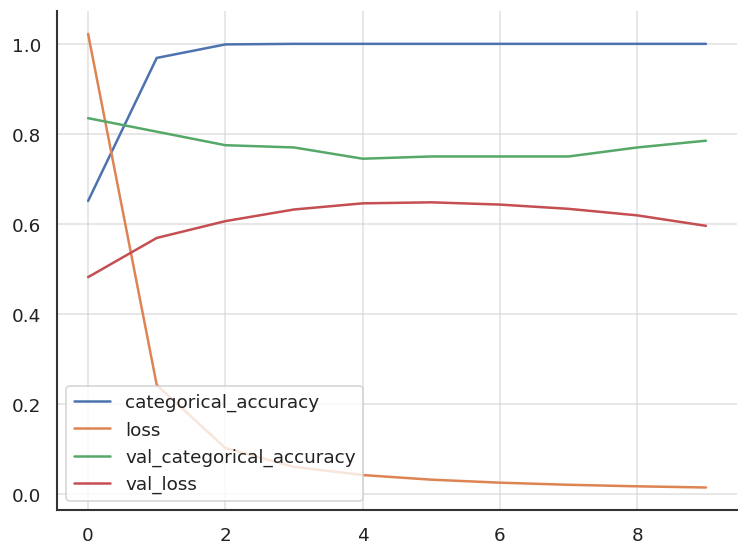

In [60]:
history = model.fit(train_x_resized, train_y, validation_split=0.2, batch_size=32, epochs=10, callbacks=[model_checkpoint_callback])

show_history(history)

In [61]:
# Load best setup
model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x_resized, test_y)
print('Test accuracy: ', test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - categorical_accuracy: 0.8172 - loss: 0.5405
Test accuracy:  0.8199999928474426


## Now you are an absolute expert in CNN applications in the image classification tasks 👏 

## We can switch to time series processing part of the lecture! 🙂
* 🔎What tasks can you imagine for time series processing?
* We will use CNN again, but now in Conv1D variant
    * 🔎 What is the difference among the 1 - 3D Conv?

### There is definitely a cool mathematical expression for each conv layer type however I would like you to understand the topic so we will use the diagrams below 🙂

![Meme02](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_meme_tf_02.png?raw=true)

### 📒 Conv2D
* Conv2D is generally used on Image data. 
* It is called 2 dimensional CNN because the kernel slides along 2 dimensions on the data as shown in the following image.

![Conv2D](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_04_conv2d.png?raw=true)


### 📒 Conv1D
* Following plot illustrate how the kernel will move on accelerometer data. 
* Each row represents time series acceleration for some axis. 
    * The kernel can only move in one dimension along the axis of time.

![Conv1D](https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/blob/main/images/dl_04_conv1d.png?raw=true)

# 📌 Summary
* In 1D CNN, kernel moves in 1 direction. Input and output data of 1D CNN is 2 dimensional. Mostly used on Time-Series data.
* In 2D CNN, kernel moves in 2 directions. Input and output data of 2D CNN is 3 dimensional. Mostly used on Image data.
* In 3D CNN, kernel moves in 3 directions. Input and output data of 3D CNN is 4 dimensional. Mostly used on 3D Image data (MRI, Video).
    * 💡 You can check https://towardsdatascience.com/understanding-1d-and-3d-convolution-neural-network-keras-9d8f76e29610 for more details

# Download the FordA data

* Let's download [FordA](https://www.timeseriesclassification.com/description.php?Dataset=FordA) dataset converted for our purposes to the [Feather file format](https://arrow.apache.org/docs/python/feather.html), a binary file format for data exchange.

* 💡 The classification problem is to diagnose whether a certain symptom exists or does not exist in an automotive subsystem.
    * Each case consists of 500 measurements of engine noise and a classification.

* 💡 The data originates from ARFF file format used in Weka Data analysis tool and has classes labeled $\{-1,1\}$ 
    * We will convert it to the $\{0,1\}$ set

In [62]:
train = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TRAIN.feather')
test = pd.read_feather('https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets/FordA_TEST.feather')
train.target.replace({-1:0}, inplace=True)
test.target.replace({-1:0}, inplace=True)
print('Train: ',train.shape)
print('Test: ', test.shape)

Train:  (3601, 501)
Test:  (1320, 501)


/tmp/ipykernel_572/3136286868.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.target.replace({-1:0}, inplace=True)
/tmp/ipykernel_572/3136286868.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

## ⚡ We can take a look at the data
* The data contain 500 time steps of a measurement and single target value. 
* The time series is almost normalized and it is not necessary to deal with it using scaling or normalizing. 
    * It may slightly improve the results but it depends on your experiments. 

### 🔎 What would you do if the time-series was continual sequence?
* How to preprocesss such data and feed it into ANN?

/tmp/ipykernel_572/462031761.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(train.iloc[idx][:-1], c=colors[int(train.iloc[idx][-1])])


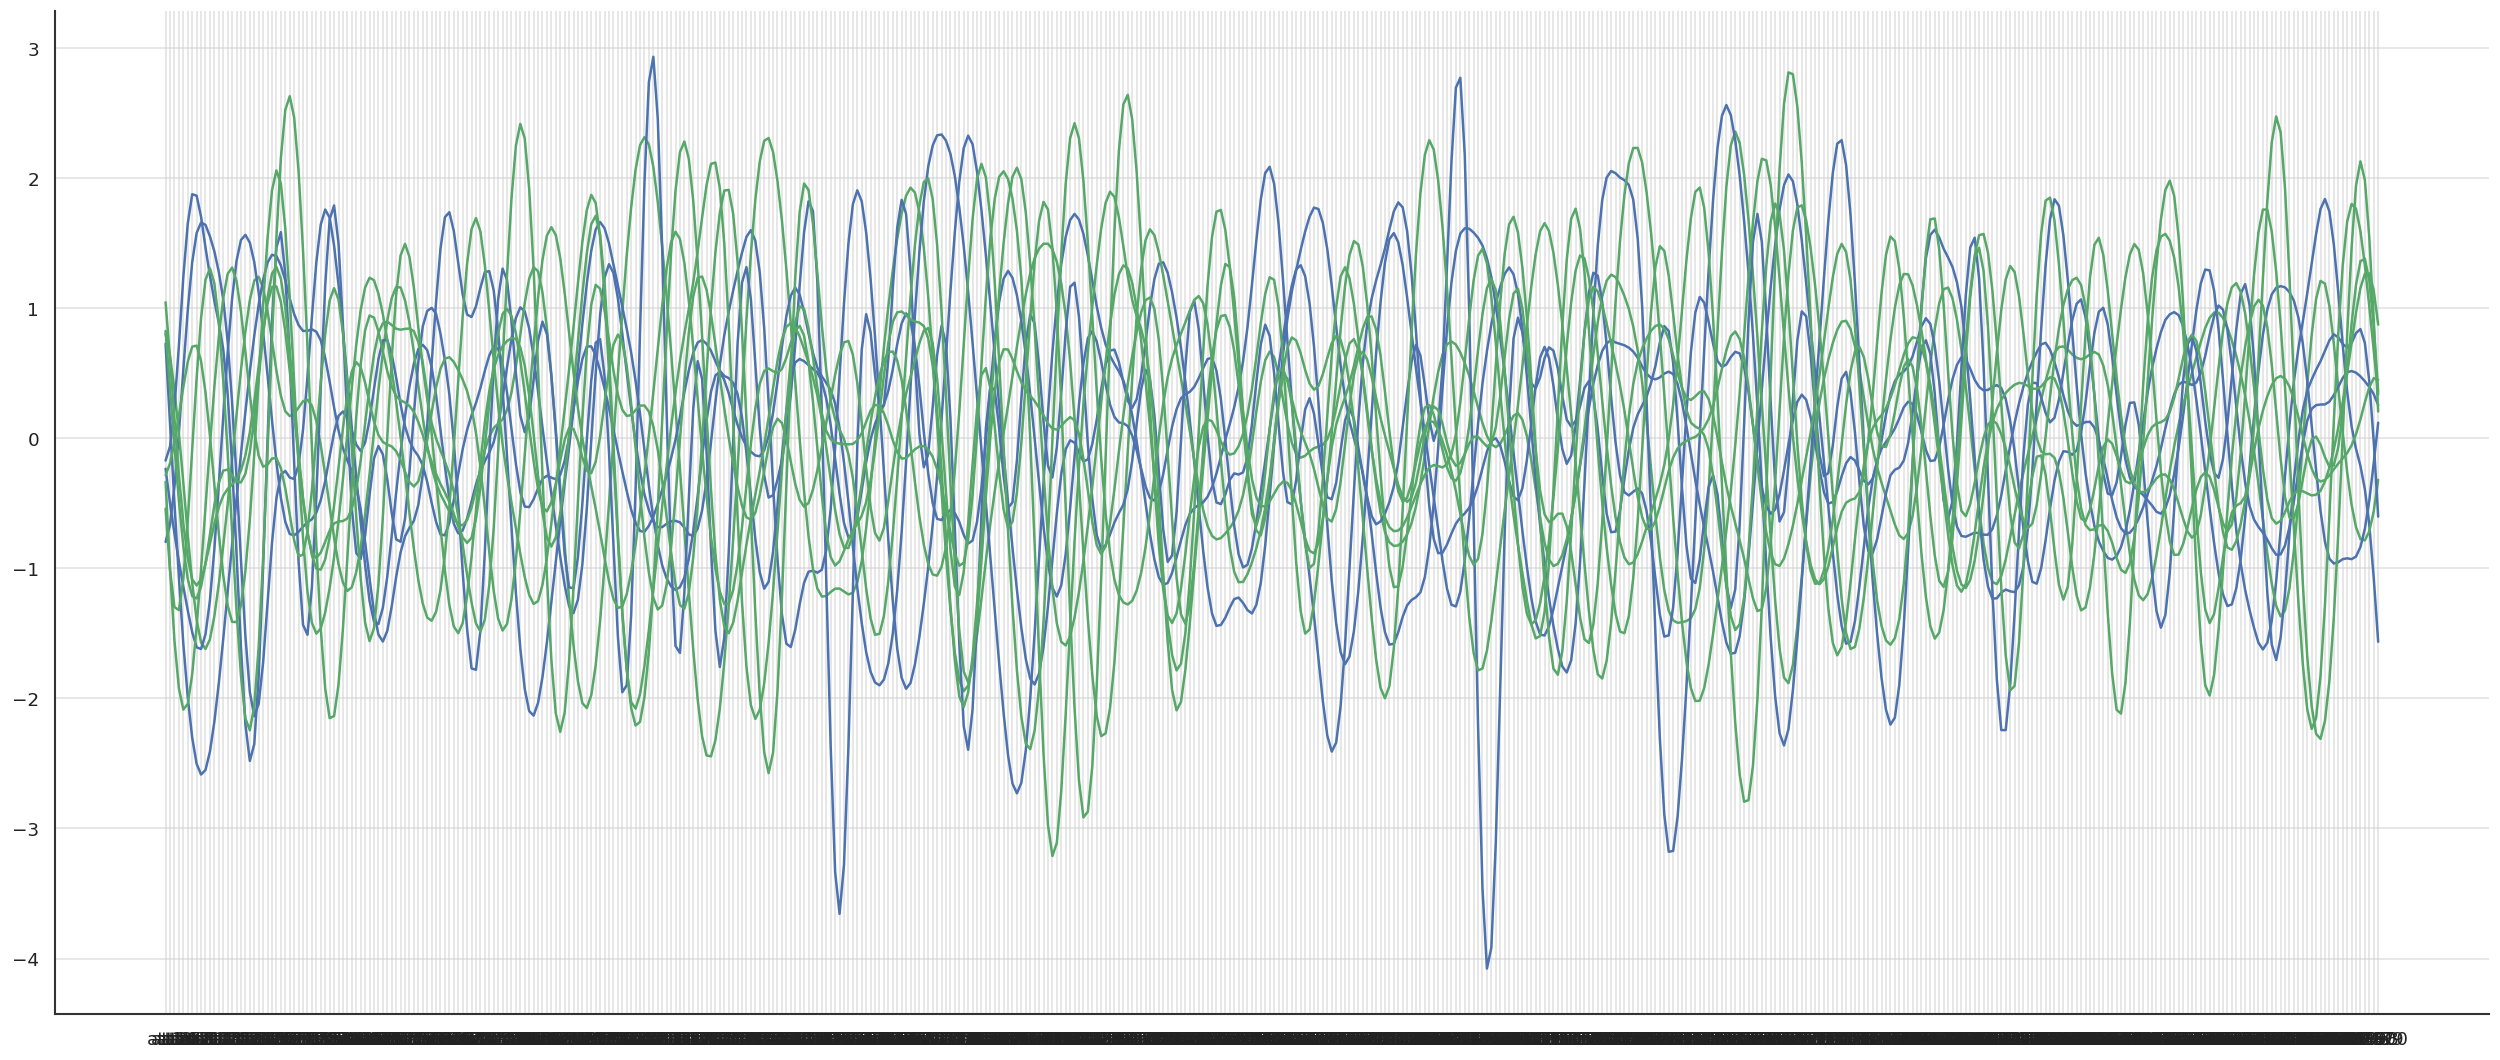

In [63]:
colors = ['b', 'g']
plt.figure(figsize=(21,9))
for idx in range(10):
  plt.plot(train.iloc[idx][:-1], c=colors[int(train.iloc[idx][-1])])
plt.tight_layout()
plt.show()

In [64]:
train.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att492,att493,att494,att495,att496,att497,att498,att499,att500,target
0,-0.797172,-0.664392,-0.373015,0.040815,0.526936,0.984288,1.353120,1.578108,1.659251,1.640809,...,0.722417,0.362068,0.092083,-0.081268,-0.212573,-0.391456,-0.664392,-1.073796,-1.564343,0
1,0.804855,0.634629,0.373474,0.038343,-0.340988,-0.740860,-1.109667,-1.395357,-1.570192,-1.619951,...,0.049213,-0.258138,-0.510583,-0.683647,-0.773817,-0.785255,-0.714885,-0.560443,-0.319086,1
2,0.727985,0.111284,-0.499124,-1.068629,-1.578351,-1.990534,-2.302031,-2.503403,-2.585211,-2.550600,...,0.463685,0.507735,0.517174,0.504588,0.476270,0.438513,0.394463,0.339400,0.255391,0
3,-0.234439,-0.502157,-0.732488,-0.946128,-1.139739,-1.323336,-1.490243,-1.607077,-1.620430,-1.506933,...,-0.929437,-0.922761,-0.929437,-0.909409,-0.835970,-0.695768,-0.478790,-0.188707,0.119736,0
4,-0.171328,-0.062285,0.235829,0.710396,1.239969,1.649823,1.876321,1.865535,1.703751,1.466467,...,0.725496,0.697453,0.731967,0.808545,0.839823,0.733046,0.437520,-0.026585,-0.602213,0


In [65]:
train.groupby('target').mean()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att491,att492,att493,att494,att495,att496,att497,att498,att499,att500
target,,,,,,,,,,,,,,,,,,,,,
0,-0.014895,-0.015515,-0.016355,-0.016704,-0.015422,-0.011477,-0.006306,-0.001435,0.002810,0.004730,...,0.020576,0.014972,0.006110,-0.003215,-0.010949,-0.014388,-0.012541,-0.006267,0.002245,0.010434
1,-0.018616,-0.015013,-0.010712,-0.006936,-0.004227,-0.002419,-0.000538,0.002675,0.008029,0.015609,...,-0.003742,-0.001601,0.001889,0.005288,0.007573,0.008220,0.006549,0.002857,-0.002297,-0.008113


In [66]:
train.groupby('target').std()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att491,att492,att493,att494,att495,att496,att497,att498,att499,att500
target,,,,,,,,,,,,,,,,,,,,,
0,1.046503,1.038535,1.030145,1.031180,1.041815,1.051984,1.053741,1.048960,1.042726,1.03680,...,1.037209,1.037731,1.034531,1.025603,1.011854,0.997298,0.987655,0.990511,1.007039,1.028501
1,1.071179,1.066081,1.059798,1.054695,1.052556,1.053998,1.057515,1.060192,1.058752,1.05203,...,1.038403,1.043903,1.047698,1.048433,1.045641,1.040933,1.036925,1.035120,1.035589,1.036879


([], [])

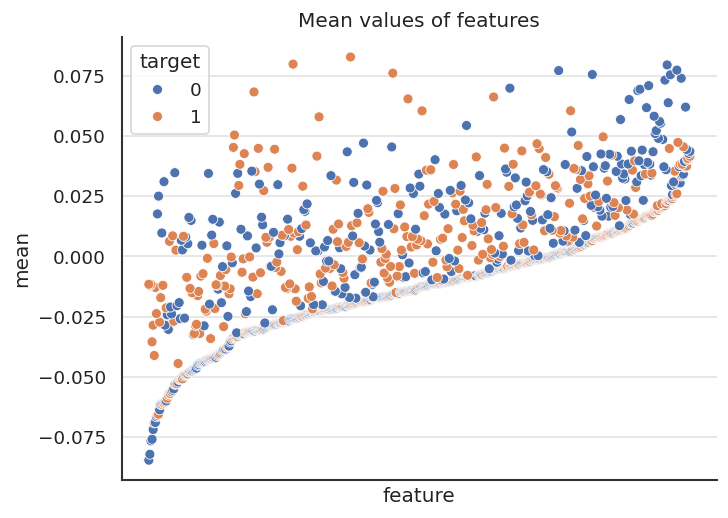

In [67]:
train.groupby('target').mean().stack().reset_index(name='mean').rename(columns={'level_1':'feature'}).sort_values('mean')
sns.scatterplot(data=train.groupby('target').mean().stack().reset_index(name='mean').rename(columns={'level_1':'feature'}).sort_values('mean'), y='mean', x='feature', hue='target').set_title('Mean values of features')
plt.xticks([])

# Check the labels balance
* 🔎 Which metrics can we use? Why?

In [68]:
train.target.value_counts()

,count
target,
0,1846
1,1755


# Convert the data into numpy arrays and separates *X* and *y* data from each other for training and testing data.

In [69]:
train_x, train_y = train.drop(columns=['target']).values, train.target.values
test_x, test_y = test.drop(columns=['target']).values, test.target.values

## ⚡ Create a baseline model
* Lets try some simple basic model on the data. DecisionTree and RandomForrest. 
    * As you will see it is a difficult task for them to get high accuracy results.

In [70]:
base_models = [DecisionTreeClassifier(random_state=13), RandomForestClassifier(random_state=13)]

for model in base_models:
    model.fit(train_x, train_y)
    y_pred = model.predict(test_x)
    print(type(model).__name__)
    compute_metrics(test_y, y_pred)

DecisionTreeClassifier
	Accuracy:    56.36%
RandomForestClassifier
	Accuracy:    73.18%


## Fully connected ANN model
* Let's try some basic neural network model for this task. 
    * It is a typical Dense network with two hidden layers and dropout optimization - it should be able to beat the Randomforrest classifier.

In [71]:
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=train_x[0].shape),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 256)            │       128,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,561 (822.50 KB)

 Trainable params: 210,561 (822.50 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - binary_accuracy: 0.5868 - loss: 0.6772 - val_binary_accuracy: 0.6810 - val_loss: 0.5889
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7606 - loss: 0.5122 - val_binary_accuracy: 0.7184 - val_loss: 0.6038
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8086 - loss: 0.4344 - val_binary_accuracy: 0.7268 - val_loss: 0.6174
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8208 - loss: 0.3935 - val_binary_accuracy: 0.7171 - val_loss: 0.5839
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8502 - loss: 0.3314 - val_binary_accuracy: 0.7379 - val_loss: 0.5796
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8723 - loss: 0.2973 - val_binary_accuracy: 0.7559 - val_loss: 0.5589
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8983 - loss: 0.2522 - val_binary_accuracy: 0.7462 - val_loss: 0.5918
Epoch 8/10
90/90 ━━

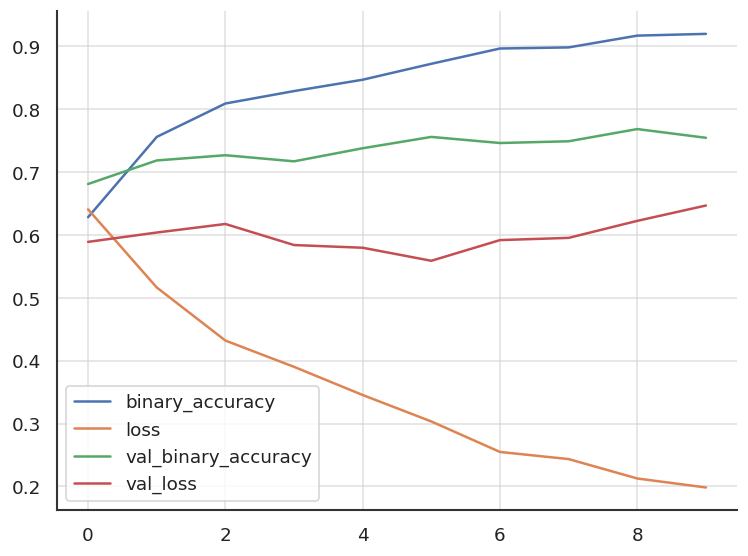

In [73]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

# 🚀 Now we will finally use the CNN! 🙂
* To use convolution in single dimension we need to reshape the data to have the proper format. 
    * The format is the same as for RNN and must be in a format $(number\_of\_vectors, vector\_length,number\_of\_dimensions)$
        * Given the user experience for the time series analysis tasks in Tensorflow, sharing the same input format between CNN and RNN must've been an accident 😅

In [74]:
train_xc = np.reshape(train_x, (*train_x.shape, 1))
test_xc = np.reshape(test_x, (*test_x.shape, 1))
train_xc.shape, test_xc.shape

((3601, 500, 1), (1320, 500, 1))

## Let's try the single convolution layer as a input mapping 
* It generates a huge number of weights for Dense layers after flattening

* The results are far from excelent
    * 🔎 Why?

In [75]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=train_xc[0].shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 498, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 31872)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │     2,039,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,040,193 (7.78 MB)

 Trainable params: 2,040,193 (7.78 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - binary_accuracy: 0.4981 - loss: 0.7673 - val_binary_accuracy: 0.5798 - val_loss: 0.6654
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.6396 - loss: 0.6308 - val_binary_accuracy: 0.6366 - val_loss: 0.6299
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.7164 - loss: 0.5552 - val_binary_accuracy: 0.6685 - val_loss: 0.5968
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7732 - loss: 0.4746 - val_binary_accuracy: 0.6699 - val_loss: 0.6211
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8035 - loss: 0.4229 - val_binary_accuracy: 0.6768 - val_loss: 0.6340
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8342 - loss: 0.3775 - val_binary_accuracy: 0.6879 - val_loss: 0.6446
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.8541 - loss: 0.3358 - val_binary_accuracy: 0.6838 - val_loss: 0.6562
Epoch 8/10
90/90 ━━

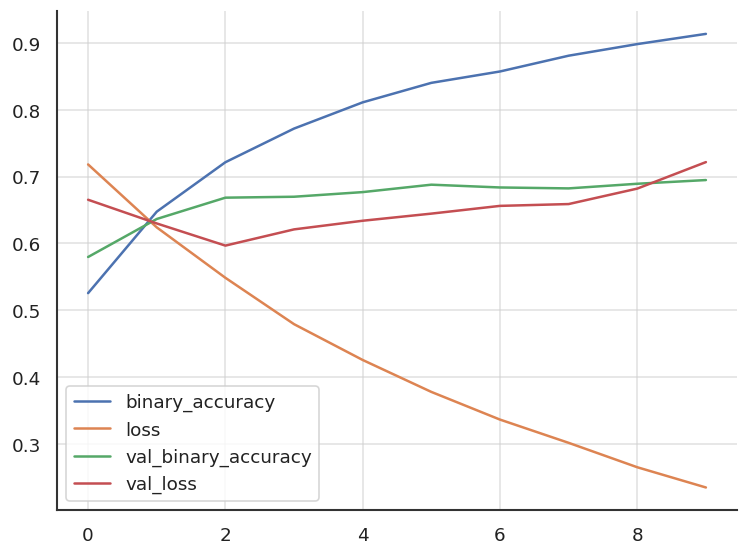

In [77]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

## A slightly more complicated model is able to beat all previous models with smaller number of weights needed

In [78]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=train_xc[0].shape),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 498, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 496, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 248, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 246, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 244, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │       999,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,036,865 (3.96 MB)

 Trainable params: 1,036,865 (3.96 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - binary_accuracy: 0.5132 - loss: 0.6770 - val_binary_accuracy: 0.6616 - val_loss: 0.5406
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.7527 - loss: 0.4616 - val_binary_accuracy: 0.8141 - val_loss: 0.3800
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8596 - loss: 0.3018 - val_binary_accuracy: 0.8738 - val_loss: 0.3219
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8787 - loss: 0.2661 - val_binary_accuracy: 0.8058 - val_loss: 0.3812
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.8815 - loss: 0.2599 - val_binary_accuracy: 0.8391 - val_loss: 0.3509
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9204 - loss: 0.1809 - val_binary_accuracy: 0.8363 - val_loss: 0.3662
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9544 - loss: 0.1249 - val_binary_accuracy: 0.8044 - val_loss: 0.4764
Epoch 8/10
90/90 ━━

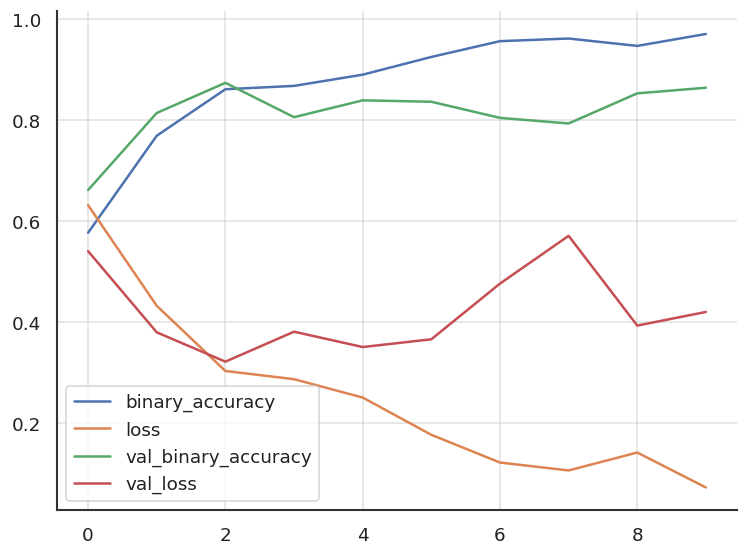

In [80]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

## Even more capable model with more pooling layers but with 1/4 weight of the previsou model is able to achieve more than 90% of the accuracy

In [81]:
model = keras.Sequential([
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=train_xc[0].shape),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer=keras.optimizers.Adam(), loss = keras.losses.BinaryCrossentropy(from_logits=False), metrics = [keras.metrics.BinaryAccuracy()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 498, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 249, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 247, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 121, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 58, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3712)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │       237,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,009 (1.05 MB)

 Trainable params: 275,009 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - binary_accuracy: 0.5415 - loss: 0.6611 - val_binary_accuracy: 0.7184 - val_loss: 0.4621
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8048 - loss: 0.3982 - val_binary_accuracy: 0.9071 - val_loss: 0.2663
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.8884 - loss: 0.2638 - val_binary_accuracy: 0.9126 - val_loss: 0.2411
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9147 - loss: 0.2223 - val_binary_accuracy: 0.9182 - val_loss: 0.2296
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9092 - loss: 0.2100 - val_binary_accuracy: 0.9057 - val_loss: 0.2338
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9202 - loss: 0.1956 - val_binary_accuracy: 0.8863 - val_loss: 0.2850
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.9231 - loss: 0.1801 - val_binary_accuracy: 0.8974 - val_loss: 0.2888
Epoch 8/10
90/90 ━━

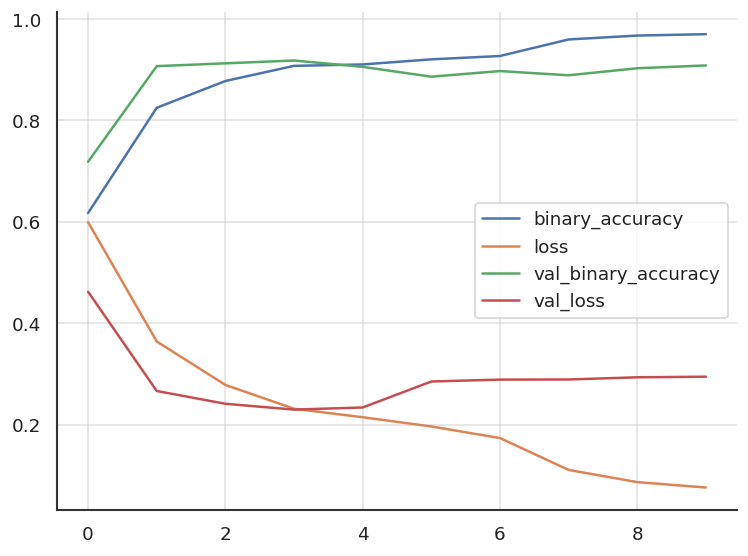

In [83]:
history = model.fit(train_x, train_y, validation_split=0.2, epochs=10, batch_size=32, callbacks=[model_checkpoint_callback])
show_history(history)

model.load_weights("best.weights.h5")
test_loss, test_acc = model.evaluate(test_x, test_y)
print('Test accuracy: ', test_acc)

# ✅  Tasks for the lecture (2p)

1) Choose any of the models from [Keras pre-trained models](https://keras.io/api/applications/) - **(1p)**

    * Investigate its' architecture
    * Search for the needed input shape for the model - remeber to preprocess the data and call correct `preprocess_input` function
        * 💡 There could be more variants of the model, the choice depends on you
    * Use the selected model for CIFAR-10 classification, 
        * Fine-tune it, experiment with it and write down your conclusions!
    
2) Define your own model for the FordA data task  - **(1p)**

    * Try to beat defined models or have at least the same accuracy score
        * 💡 You can also try to minimize the number of parameters for having approx. the same accuracy as we do!
    * Experiment with the model and write down your conclusions!

Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - acc: 0.1604 - loss: 2.8496 - val_acc: 0.5000 - val_loss: 1.5655 - learning_rate: 0.0010
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - acc: 0.4775 - loss: 1.6328 - val_acc: 0.6650 - val_loss: 1.1855 - learning_rate: 0.0010
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - acc: 0.5909 - loss: 1.3013 - val_acc: 0.7050 - val_loss: 1.0240 - learning_rate: 0.0010
Epoch 4/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - acc: 0.7147 - loss: 1.0546 - val_acc: 0.7400 - val_loss: 0.9575 - learning_rate: 0.0010
Epoch 5/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - acc: 0.7129 - loss: 0.9646 - val_acc: 0.7550 - val_loss: 0.9140 - learning_rate: 0.0010
Epoch 6/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - acc: 0.7783 - loss: 0.8774 - val_acc: 0.7700 - val_loss: 0.9038 - learning_rate: 0.0010
Epoch 7/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - acc: 0.7997 - loss: 0.7998 - val_acc: 0.7750 - val_loss: 0.8948 - learning_rate: 0.0010
Epoch 8/8
25/25 ━

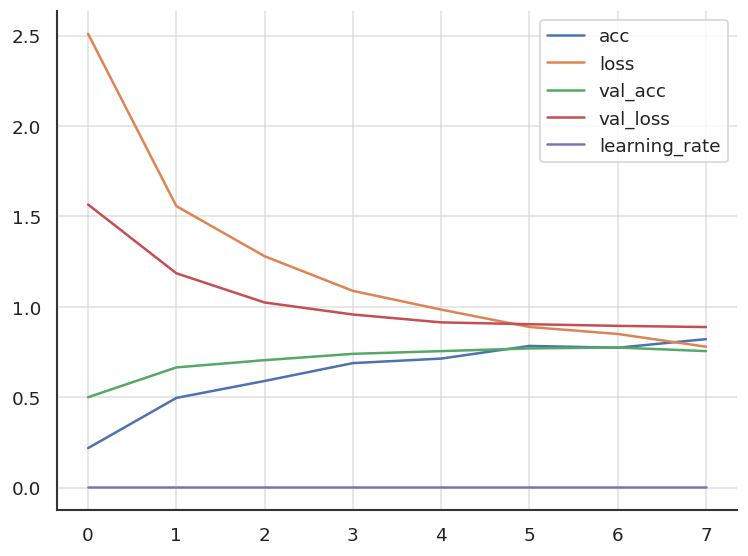

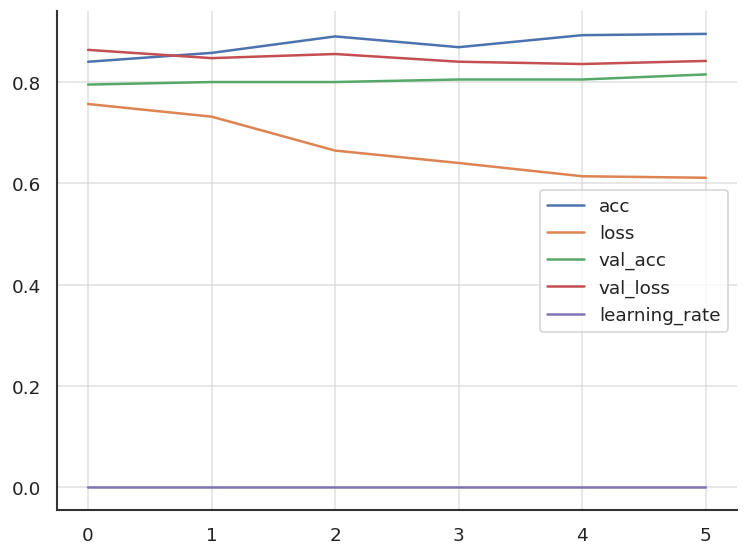

In [84]:
tf.keras.utils.set_random_seed(42)

cifar_train_x = np.asarray(train_x_resized)
cifar_test_x = np.asarray(test_x_resized)
(_, cifar_train_y_raw), (_, cifar_test_y_raw) = dataset.load_data()
cifar_train_y = tf.keras.utils.to_categorical(cifar_train_y_raw[:subset], class_count)
cifar_test_y = tf.keras.utils.to_categorical(cifar_test_y_raw[:subset], class_count)

x_train_cifar, x_val_cifar, y_train_cifar, y_val_cifar = train_test_split(
    cifar_train_x,
    cifar_train_y,
    test_size=test_size,
    random_state=42,
    stratify=np.argmax(cifar_train_y, axis=1),
)

augment = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomTranslation(0.05, 0.05),
])

mobilenet_base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(img_size, img_size, 3),
)
mobilenet_base.trainable = False

cifar_inputs = keras.Input(shape=(img_size, img_size, 3))
x = augment(cifar_inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = mobilenet_base(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.35)(x)
cifar_outputs = keras.layers.Dense(class_count, activation='softmax')(x)
cifar_model = keras.Model(cifar_inputs, cifar_outputs, name='cifar_mobilenetv2')

cifar_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='cifar_mobilenetv2_best.weights.h5',
        save_weights_only=True,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6),
]

cifar_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc')],
)

history_cifar_frozen = cifar_model.fit(
    x_train_cifar,
    y_train_cifar,
    validation_data=(x_val_cifar, y_val_cifar),
    epochs=8,
    batch_size=32,
    callbacks=cifar_callbacks,
    verbose=1,
)

mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-40]:
    layer.trainable = False
for layer in mobilenet_base.layers[-40:]:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

cifar_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[keras.metrics.CategoricalAccuracy(name='acc')],
)

history_cifar_ft = cifar_model.fit(
    x_train_cifar,
    y_train_cifar,
    validation_data=(x_val_cifar, y_val_cifar),
    epochs=6,
    batch_size=32,
    callbacks=cifar_callbacks,
    verbose=1,
)

cifar_model.load_weights('cifar_mobilenetv2_best.weights.h5')
cifar_test_loss, cifar_test_acc = cifar_model.evaluate(cifar_test_x, cifar_test_y, verbose=0)
print(f'CIFAR-10 test accuracy (MobileNetV2): {cifar_test_acc:.4f}')
show_history(history_cifar_frozen)
show_history(history_cifar_ft)

FordA train class distribution:
0.0    0.512635
1.0    0.487365
Name: proportion, dtype: float64
Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - acc: 0.7423 - loss: 0.5234 - val_acc: 0.4868 - val_loss: 0.7001 - learning_rate: 8.0000e-04
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.8969 - loss: 0.2622 - val_acc: 0.4868 - val_loss: 0.6930 - learning_rate: 8.0000e-04
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9117 - loss: 0.2152 - val_acc: 0.4868 - val_loss: 0.6920 - learning_rate: 8.0000e-04
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.9184 - loss: 0.2020 - val_acc: 0.4868 - val_loss: 0.6885 - learning_rate: 8.0000e-04
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9200 - loss: 0.1923 - val_acc: 0.8183 - val_loss: 0.6779 - learning_rate: 8.0000e-04
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9324 - loss: 0.1790 - val_acc: 0.6671 - val_loss: 0.6597 - learning_rate: 8.0000e-04
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━

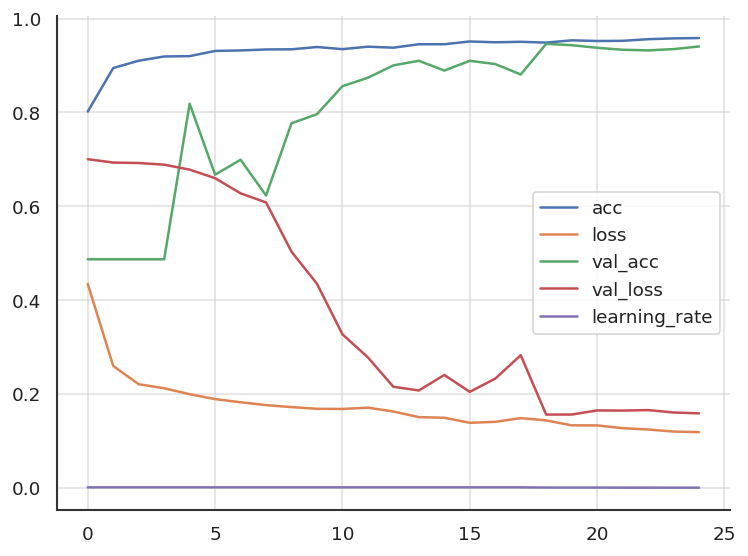

In [85]:
ford_train_x, ford_test_x = train_xc, test_xc
ford_train_y, ford_test_y = train_y, test_y

ford_train_x = ford_train_x.astype(np.float32, copy=False)
ford_test_x = ford_test_x.astype(np.float32, copy=False)
ford_train_y = ford_train_y.astype(np.float32, copy=False)
ford_test_y = ford_test_y.astype(np.float32, copy=False)

print('FordA train class distribution:')
print(pd.Series(ford_train_y).value_counts(normalize=True).sort_index())

x_train_ford, x_val_ford, y_train_ford, y_val_ford = train_test_split(
    ford_train_x,
    ford_train_y,
    test_size=0.2,
    random_state=42,
    stratify=ford_train_y.astype(int),
)

ford_model = keras.Sequential([
    keras.layers.Input(shape=ford_train_x[0].shape),
    keras.layers.Conv1D(64, kernel_size=7, padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool1D(2),
    keras.layers.SeparableConv1D(128, kernel_size=5, padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool1D(2),
    keras.layers.SeparableConv1D(128, kernel_size=3, padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dropout(0.35),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
], name='forda_custom_cnn_v2')

ford_model.compile(
    optimizer=keras.optimizers.Adam(8e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name='acc')],
)

ford_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='forda_custom_best.weights.h5',
        save_weights_only=True,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
]

history_ford = ford_model.fit(
    x_train_ford,
    y_train_ford,
    validation_data=(x_val_ford, y_val_ford),
    epochs=40,
    batch_size=64,
    callbacks=ford_callbacks,
    verbose=1,
)

ford_model.load_weights('forda_custom_best.weights.h5')
ford_test_loss, ford_test_acc = ford_model.evaluate(ford_test_x, ford_test_y, verbose=0)
ford_pred = (ford_model.predict(ford_test_x, verbose=0).ravel() >= 0.5).astype(int)

print(f'FordA test accuracy (custom Conv1D v2): {ford_test_acc:.4f}')
compute_metrics(ford_test_y.astype(int), ford_pred, show_confusion_matrix=True)
print(f'Pocet parametru modelu: {ford_model.count_params():,}')
show_history(history_ford)

## Odpoved na ukol 4 (jednoduse)

### 1) Vybrany model pro CIFAR-10: MobileNetV2

**Proc jsem ho vybral:**
- je rychly,
- ma malo parametru,
- dobre funguje i na slabsim HW.

**Jednoduche zajimavosti o architekture:**
- Model dela klasifikaci po krocich od jednoduchych tvaru k slozitejsim.
- Je navrzeny tak, aby byl "lehky" a nebyl moc pomaly.
- Proto se casto pouziva i v mobilech.

**Input shape a preprocessing:**
- Pouzil jsem vstup `224x224x3`.
- CIFAR-10 ma puvodne `32x32`, takze obrazky jsem nejdriv zvetsil.
- Pred modelem jsem pouzil spravnou funkci:
  `tf.keras.applications.mobilenet_v2.preprocess_input(...)`.

### Jednoduche odpovedi na otazky z notebooku

**Co dela `include_top=False`?**
- Odstrani puvodni posledni vrstvu modelu.
- Ja si pak pridam svoji posledni vrstvu pro 10 trid CIFAR-10.

**Co znamena `weights='imagenet'`?**
- Model uz je predem nauceny na velkem datasetu ImageNet.

**Potrebujeme to?**
- Pro maly dataset vetsinou ano, trenink je pak rychlejsi a stabilnejsi.

**Co kdyz dam nahodne vahy?**
- Model zacina od nuly, trenuje se dele a obvykle ma horsi vysledek.

**Proc pri fine-tuningu pouzivame maly learning rate?**
- Aby se uz naucene dobre vlastnosti modelu "nepokazily" moc velkymi zmenami.

**Co znamena "odemknout poslednich 40 vrstev"?**
- Ze posledni cast modelu nastavim jako trenovatelnou (`trainable=True`).
- Tyto vrstvy se pak muzou ucit z nasich dat a prizpusobit se CIFAR-10.

**Proc se odemykaji jen posledni vrstvy a ne cely model?**
- Spodni vrstvy vetsinou umi obecne veci (hrany, tvary), ty neni nutne moc menit.
- Horni vrstvy jsou vic "specializovane", a proto je vyhodne je jemne doucit.
- Je to bezpecnejsi proti preuceni nez odemknout vsechno najednou.

**Jak probiha trenovani krok za krokem?**
- Krok 1: model je zamrazeny, trenuje se jen nova hlavicka.
- Krok 2: odemknu poslednich ~40 vrstev a zmensim learning rate.
- Krok 3: model znovu zkompiluju a pokracuju v trenovani (to je fine-tuning).
- Krok 4: prubezne hlidam validacni chybu/presnost a zastavim trenink, kdyz se to uz nelepsi.

### Muj vysledek na CIFAR-10

- `CIFAR-10 test accuracy (MobileNetV2): 0.7870`

**Muj jednoduchy zaver:**
- Predtrenovany model byl dobra volba.
- Fine-tuning pomohl model jeste trochu vylepsit.

---

### 2) Muj vlastni model pro FordA

**Model (jednoduse):**
- nekolik 1D konvolucnich vrstev,
- normalizace,
- pooling,
- na konci jednoducha klasifikace.

**Muj vysledek:**
- `FordA test accuracy (custom Conv1D v2): 0.9409`
- `Pocet parametru modelu: 35,649`

**Muj jednoduchy zaver:**
- Model je docela maly, ale presny.
- Pro FordA funguje velmi dobre a je efektivni.